# Préparation des données pour la modélisation

Objectifs :
- partir du DataFrame central construit à l’étape 1
- identifier les variables à exclure ou transformer
- analyser les corrélations entre variables numériques
- encoder les variables qualitatives
- construire un DataFrame `X` prêt pour la modélisation et une cible `y`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df_central = pd.read_csv("../data/processed/df_central.csv")

## Inspection initiale du DataFrame central

In [2]:
print(df_central.shape)
display(df_central.head())
df_central.info()

(1470, 32)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travaillees,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annees_sous_responsable_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,1,0,0,1,1,2,Infra & Cloud,1,Occasionnel,0,5,2,3,2,4,1,1,3,1,11.0
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,0,1,3,1,8,1,Infra & Cloud,1,Frequent,1,7,3,2,2,2,4,3,4,0,23.0
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,1,0,3,1,2,2,Autre,1,Occasionnel,0,0,4,2,1,3,2,3,3,1,15.0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,0,0,3,1,3,4,Infra & Cloud,1,Frequent,3,0,4,3,1,3,3,3,3,1,11.0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,0,1,3,1,2,1,Transformation Digitale,1,Occasionnel,2,2,1,3,1,2,4,3,3,0,12.0


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   str    
 3   revenu_mensuel                             1470 non-null   int64  
 4   statut_marital                             1470 non-null   str    
 5   departement                                1470 non-null   str    
 6   poste                                      1470 non-null   str    
 7   nombre_experiences_precedentes             1470 non-null   int64  
 8   nombre_heures_travaillees                  1470 non-null   int64  
 9   annee_experience_totale                    1470 non-null   int64  
 10  annees_dans_l_entreprise           

## Détection des variables constantes
Les variables constantes n’apportent aucune information discriminante au modèle.  
On réalise donc une détection automatique avant la préparation des features.

In [3]:
def detect_constant_features(df):
    nunique = df.nunique(dropna=False)
    constant_cols = nunique[nunique == 1].index.tolist()
    return constant_cols

constant_cols = detect_constant_features(df_central)
constant_cols

['nombre_heures_travaillees',
 'nombre_employee_sous_responsabilite',
 'ayant_enfants']

Les colonnes constantes seront supprimées de la modélisation, car elles ne permettent pas de différencier les individus.

## Sélection initiale des variables
Certaines colonnes sont exclues avant la modélisation :
- l’identifiant technique
- les variables constantes
- la cible, qui sera isolée séparément

In [4]:
target_col = "a_quitte_l_entreprise"

cols_to_drop_initial = ["id_employee"] + constant_cols
cols_to_drop_initial = list(dict.fromkeys(cols_to_drop_initial))  # évite les doublons

print("Colonnes retirées à ce stade :", cols_to_drop_initial)

Colonnes retirées à ce stade : ['id_employee', 'nombre_heures_travaillees', 'nombre_employee_sous_responsabilite', 'ayant_enfants']


In [5]:
df_before = df_central.copy()
df_model = df_central.drop(columns=cols_to_drop_initial)

print(df_model.shape)
display(df_model.head())

(1470, 28)


,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annees_sous_responsable_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,8,6,4,1,0,0,1,2,Infra & Cloud,Occasionnel,0,5,2,3,2,4,1,1,3,1,11.0
1,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,10,10,7,0,1,3,8,1,Infra & Cloud,Frequent,1,7,3,2,2,2,4,3,4,0,23.0
2,37,M,2090,Célibataire,Consulting,Consultant,6,7,0,0,1,0,3,2,2,Autre,Occasionnel,0,0,4,2,1,3,2,3,3,1,15.0
3,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,8,8,7,0,0,3,3,4,Infra & Cloud,Frequent,3,0,4,3,1,3,3,3,3,1,11.0
4,27,M,3468,Marié(e),Consulting,Consultant,9,6,2,2,0,1,3,2,1,Transformation Digitale,Occasionnel,2,2,1,3,1,2,4,3,3,0,12.0


## Séparation des features et de la cible

In [6]:
y = df_model[target_col]
X_raw = df_model.drop(columns=[target_col])

print("Shape de X_raw :", X_raw.shape)
print("Shape de y :", y.shape)

Shape de X_raw : (1470, 27)
Shape de y : (1470,)


## Typologie des variables
On sépare les variables entre variables numériques et qualitatives, afin d’appliquer les transformations adaptées à chaque type.

In [7]:
num_cols = X_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_raw.select_dtypes(include=["object", "string"]).columns.tolist()

print("Variables numériques :")
print(num_cols)

print("\nVariables qualitatives :")
print(cat_cols)

Variables numériques :
['age', 'revenu_mensuel', 'nombre_experiences_precedentes', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'nombre_participation_pee', 'nb_formations_suivies', 'distance_domicile_travail', 'niveau_education', 'annees_depuis_la_derniere_promotion', 'annees_sous_responsable_actuel', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']

Variables qualitatives :
['genre', 'statut_marital', 'departement', 'poste', 'domaine_etude', 'frequence_deplacement']


## Corrélations entre variables numériques : Pearson
La corrélation de Pearson permet d’identifier les relations linéaires fortes entre variables numériques.

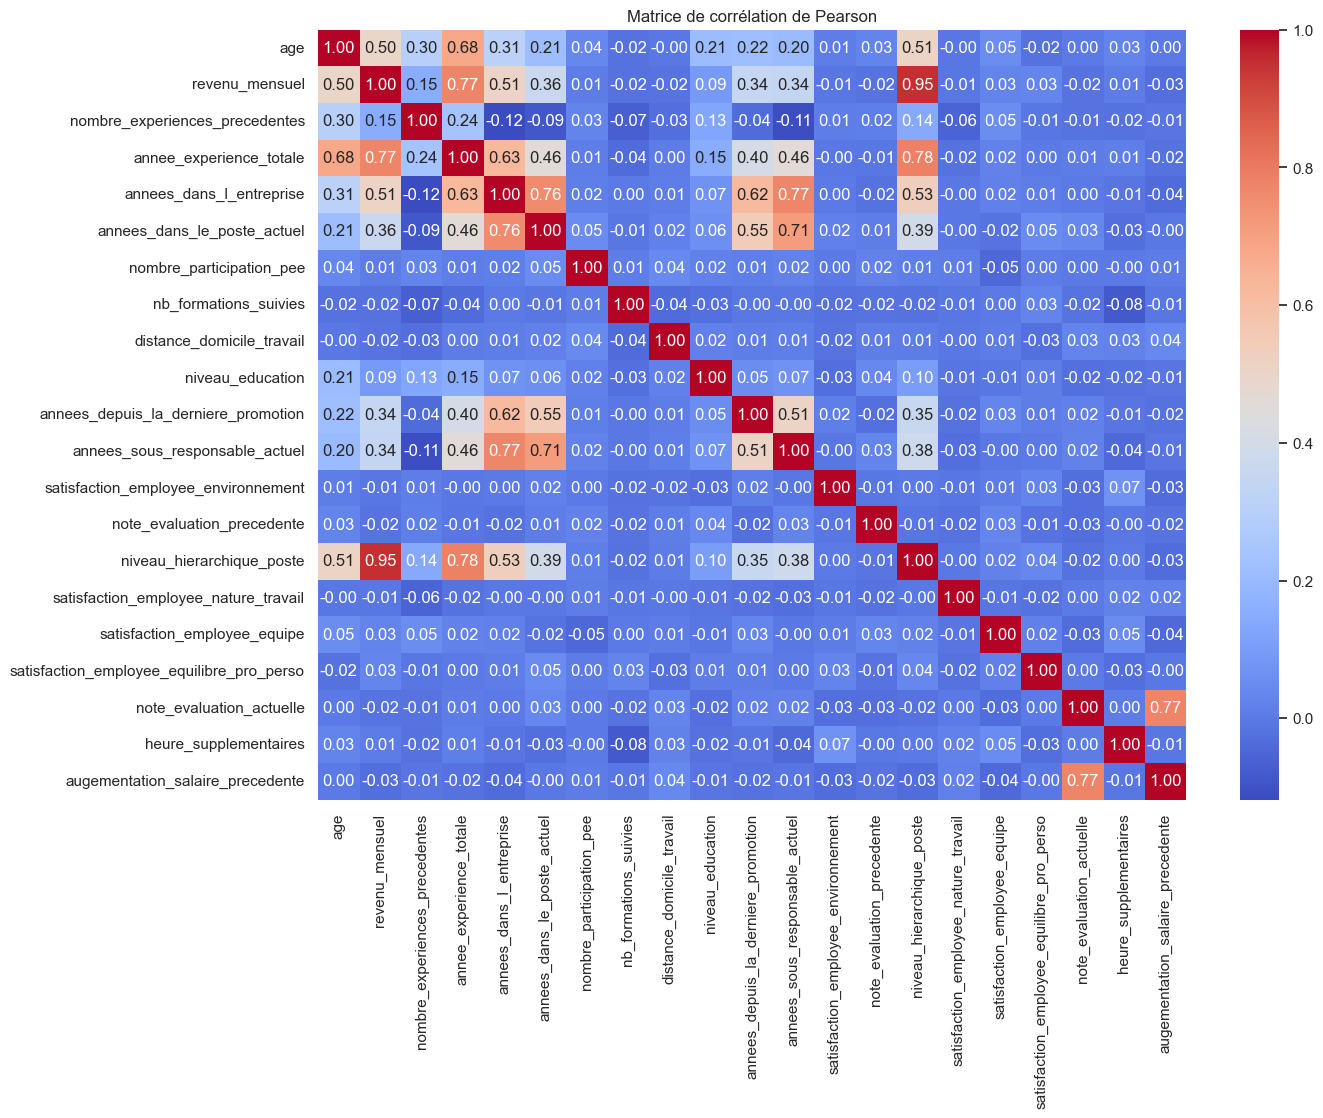

In [8]:
plt.figure(figsize=(14, 10))
corr_pearson = X_raw[num_cols].corr(method="pearson")
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation de Pearson")
plt.show()

## Corrélations entre variables numériques : Spearman
La corrélation de Spearman complète Pearson en captant mieux certaines relations monotones non strictement linéaires et en étant adaptée à certaines variables ordinales.

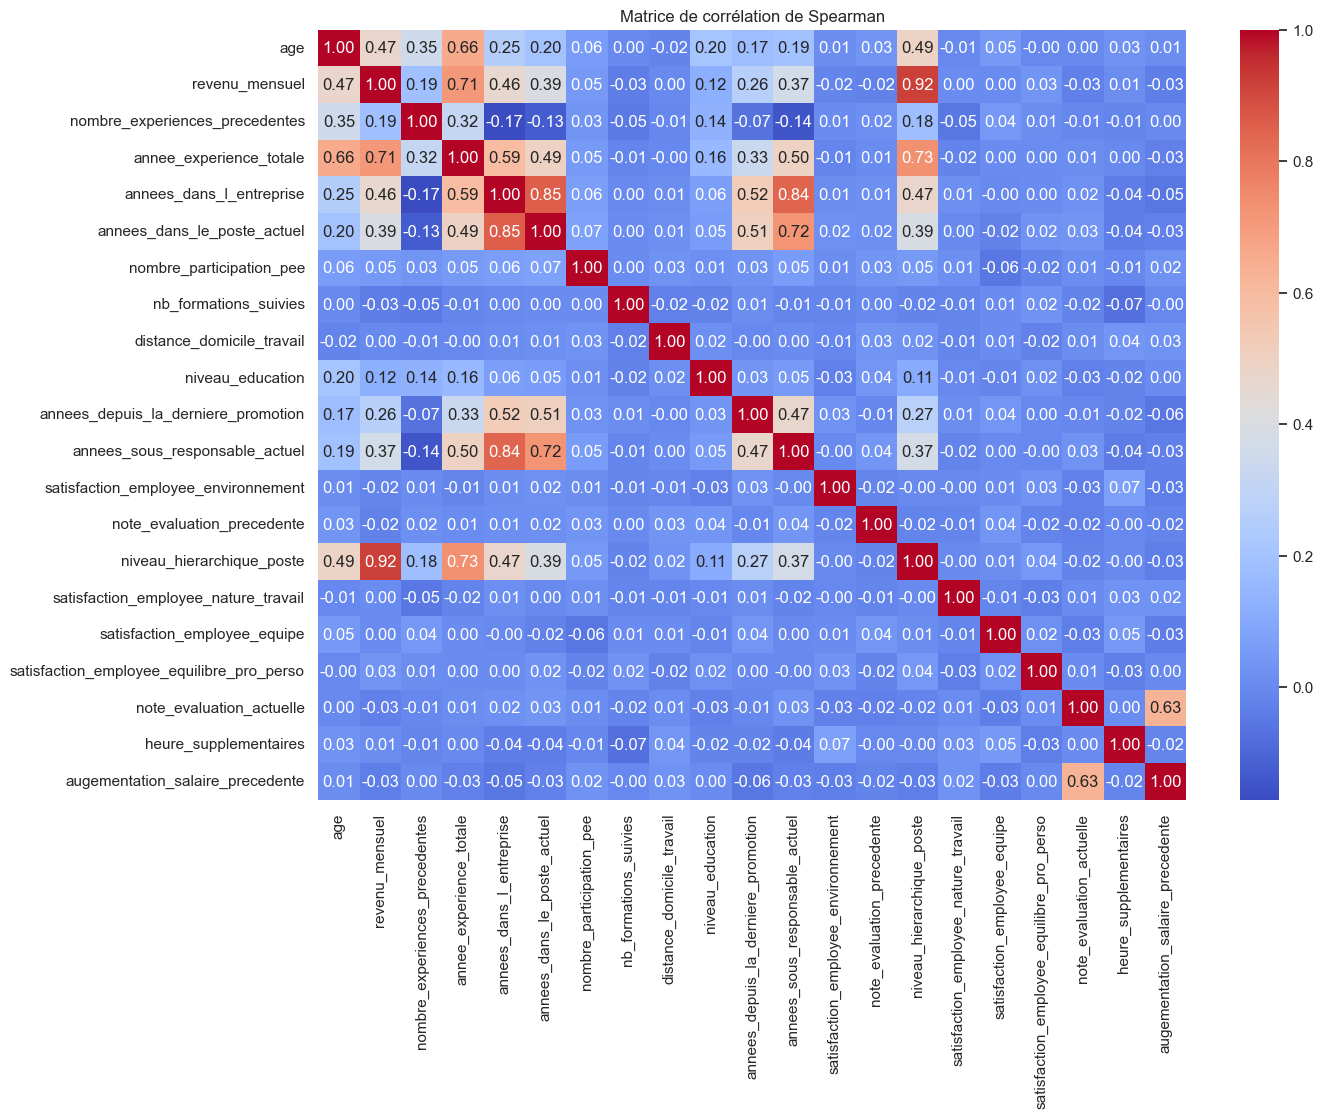

In [9]:
plt.figure(figsize=(14, 10))
corr_spearman = X_raw[num_cols].corr(method="spearman")
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation de Spearman")
plt.show()

## Identification automatique des fortes corrélations
on liste les paires de variables fortement corrélées automatiquement afin de faciliter la sélection des variables à conserver.

In [10]:
def get_high_correlations(df, threshold=0.8, method="pearson"):
    corr = df.corr(method=method).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    
    high_corr_pairs = []
    for col in upper.columns:
        for row in upper.index:
            value = upper.loc[row, col]
            if pd.notna(value) and value >= threshold:
                high_corr_pairs.append((row, col, value))
    
    return pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "correlation"])

In [11]:
high_corr_pearson = get_high_correlations(X_raw[num_cols], threshold=0.8, method="pearson")
high_corr_pearson.sort_values("correlation", ascending=False)

,feature_1,feature_2,correlation
0,revenu_mensuel,niveau_hierarchique_poste,0.9503


In [12]:
high_corr_spearman = get_high_correlations(X_raw[num_cols], threshold=0.8, method="spearman")
high_corr_spearman.sort_values("correlation", ascending=False)

,feature_1,feature_2,correlation
2,revenu_mensuel,niveau_hierarchique_poste,0.920429
0,annees_dans_l_entreprise,annees_dans_le_poste_actuel,0.854000
1,annees_dans_l_entreprise,annees_sous_responsable_actuel,0.842803


## Pairplot ciblé
On réalise un pairplot sur un sous-ensemble réduit de variables afin d’explorer visuellement d’éventuelles relations non linéaires.

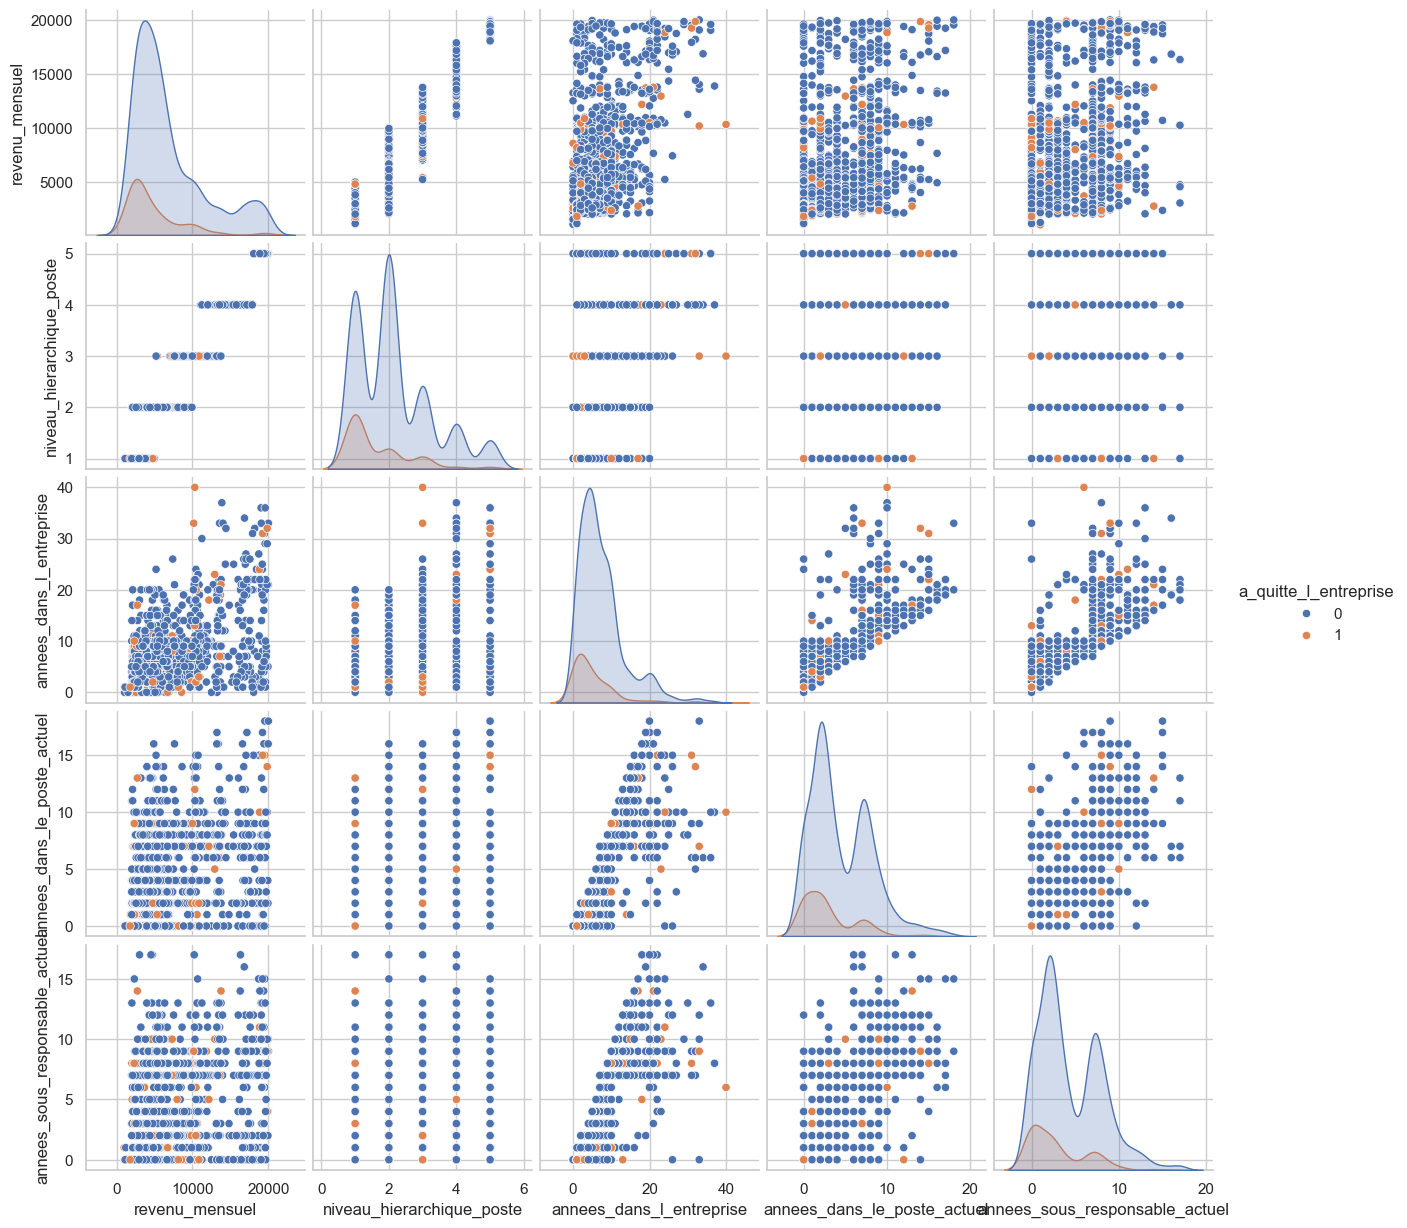

In [13]:
pairplot_cols = [
    "revenu_mensuel",
    "niveau_hierarchique_poste",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "annees_sous_responsable_actuel",
    "a_quitte_l_entreprise"
]

sns.pairplot(df_model[pairplot_cols], hue="a_quitte_l_entreprise")
plt.show()

## Sélection des variables corrélées à retirer
On ne supprime pas automatiquement les variables fortement corrélées.  
On fait ce choix en combinant la lecture des matrices de corrélation et l’interprétabilité métier.

In [14]:
cols_high_corr_to_drop = ["niveau_hierarchique_poste"]

## Encodage des variables qualitatives

On encode les variables qualitatives nominales avec un one-hot encoding, car leurs modalités n’ont pas d’ordre naturel.

La variable `frequence_deplacement` est encodée de manière ordinale, car ses modalités traduisent une intensité croissante :
- Aucun
- Occasionnel
- Frequent

In [15]:
def prepare_features(df, cols_high_corr_to_drop=None):
    df = df.copy()

    if cols_high_corr_to_drop is None:
        cols_high_corr_to_drop = []

    # 1. Détection des colonnes constantes
    constant_cols = detect_constant_features(df)

    # 2. Colonnes à supprimer
    cols_to_drop = ["id_employee"] + constant_cols + cols_high_corr_to_drop
    cols_to_drop = list(dict.fromkeys(cols_to_drop))

    # 3. Suppression
    df = df.drop(columns=cols_to_drop)

    # 4. Séparation cible / features
    y = df["a_quitte_l_entreprise"]
    X = df.drop(columns=["a_quitte_l_entreprise"])

    # 5. Encodage ordinal
    freq_map = {
        "Aucun": 0,
        "Occasionnel": 1,
        "Frequent": 2
    }
    X["frequence_deplacement"] = X["frequence_deplacement"].map(freq_map)

    # 6. One-hot encoding
    nominal_cols = [
        "genre",
        "statut_marital",
        "departement",
        "poste",
        "domaine_etude"
    ]
    X = pd.get_dummies(X, columns=nominal_cols, drop_first=True, dtype=int)

    return X, y

## Construction finale de `X` et `y`

In [16]:
X, y = prepare_features(df_central, cols_high_corr_to_drop=cols_high_corr_to_drop)

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

display(X.head())
display(y.head())

Shape de X : (1470, 39)
Shape de y : (1470,)


,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,frequence_deplacement,annees_depuis_la_derniere_promotion,annees_sous_responsable_actuel,satisfaction_employee_environnement,note_evaluation_precedente,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,genre_M,statut_marital_Divorcé(e),statut_marital_Marié(e),departement_Consulting,departement_Ressources Humaines,poste_Cadre Commercial,poste_Consultant,poste_Directeur Technique,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Senior Manager,poste_Tech Lead,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale
0,41,5993,8,8,6,4,0,0,1,2,1,0,5,2,3,4,1,1,3,1,11.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
1,49,5130,1,10,10,7,1,3,8,1,2,1,7,3,2,2,4,3,4,0,23.0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,37,2090,6,7,0,0,0,3,2,2,1,0,0,4,2,3,2,3,3,1,15.0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,33,2909,1,8,8,7,0,3,3,4,2,3,0,4,3,3,3,3,3,1,11.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,27,3468,9,6,2,2,1,3,2,1,1,2,2,1,3,2,4,3,3,0,12.0,1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1


0    1
1    0
2    1
3    0
4    0
Name: a_quitte_l_entreprise, dtype: int64

## Conclusion

On a sélectionné, nettoyé et encodé les variables afin d’obtenir :
- un DataFrame `X` entièrement numérique
- une variable cible `y` correspondant au départ ou non de l’employé
- un jeu de données compatible avec les méthodes `fit()` de scikit-learn

On a aussi examiné les corrélations entre variables afin de limiter la redondance avant la phase de modélisation.

In [17]:
X.to_csv("../data/processed/X_model.csv", index=False)
y.to_csv("../data/processed/y_model.csv", index=False)